In [1]:
!rm -rf /root/.config/Google/DriveFS


manuall authentication

In [2]:
from google.colab import auth
auth.authenticate_user()


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


install libraries

In [1]:
# MNE install karo - EEG processing ke liye
!pip install mne

# Import karo zaroori libraries
import mne
import numpy as np
import matplotlib.pyplot as plt
import os

print("Sab install ho gaya!")

Sab install ho gaya!


now load the file

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Import library
import mne
import os

# First check what's inside EEG_Project
print("Contents of EEG_Project:")
!ls -la "/content/drive/MyDrive/EEG_Project/"

# Check if dataset folder exists inside
print("\nChecking for eeg-motor-movementimagery dataset:")
!ls -la "/content/drive/MyDrive/EEG_Project/" | grep -i eeg

# Find actual path of any .edf file
print("\nSearching for any .edf file:")
!find "/content/drive/MyDrive/EEG_Project/" -name "*.edf" 2>/dev/null | head -5

Contents of EEG_Project:
ls: cannot access '/content/drive/MyDrive/EEG_Project/': No such file or directory

Checking for eeg-motor-movementimagery dataset:
ls: cannot access '/content/drive/MyDrive/EEG_Project/': No such file or directory

Searching for any .edf file:


In [4]:
# Search entire Drive for EEG_Project folder
print("Searching for EEG_Project in entire Drive:")
!find "/content/drive/MyDrive/" -type d -name "EEG_Project" 2>/dev/null

# Search for any EDF file in Drive
print("\nSearching for any .edf file in Drive:")
!find "/content/drive/MyDrive/" -name "*.edf" 2>/dev/null | head -10

# List all folders in MyDrive
print("\nAll folders in MyDrive:")
!ls -la "/content/drive/MyDrive/"

Searching for EEG_Project in entire Drive:

Searching for any .edf file in Drive:
/content/drive/MyDrive/EEG_Project /eeg-motor-movementimagery-dataset-1.0.0/files/S002/S002R14.edf
/content/drive/MyDrive/EEG_Project /eeg-motor-movementimagery-dataset-1.0.0/files/S002/S002R05.edf
/content/drive/MyDrive/EEG_Project /eeg-motor-movementimagery-dataset-1.0.0/files/S002/S002R04.edf
/content/drive/MyDrive/EEG_Project /eeg-motor-movementimagery-dataset-1.0.0/files/S002/S002R13.edf
/content/drive/MyDrive/EEG_Project /eeg-motor-movementimagery-dataset-1.0.0/files/S002/S002R11.edf
/content/drive/MyDrive/EEG_Project /eeg-motor-movementimagery-dataset-1.0.0/files/S002/S002R09.edf
/content/drive/MyDrive/EEG_Project /eeg-motor-movementimagery-dataset-1.0.0/files/S002/S002R06.edf
/content/drive/MyDrive/EEG_Project /eeg-motor-movementimagery-dataset-1.0.0/files/S002/S002R12.edf
/content/drive/MyDrive/EEG_Project /eeg-motor-movementimagery-dataset-1.0.0/files/S002/S002R08.edf
/content/drive/MyDrive/EEG_

In [5]:
# Import library
import mne

# Correct file path (notice the space after EEG_Project)
file_path = '/content/drive/MyDrive/EEG_Project /eeg-motor-movementimagery-dataset-1.0.0/files/S001/S001R04.edf'

# Load EDF file
raw = mne.io.read_raw_edf(file_path, preload=True)

# Display file info
print(raw.info)

Extracting EDF parameters from /content/drive/MyDrive/EEG_Project /eeg-motor-movementimagery-dataset-1.0.0/files/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


In [6]:
# T1 = left hand, T2 = right hand, T0 = rest
print(raw.annotations)

<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>


Cell — Signal Plot Karna

Using matplotlib as 2D backend.


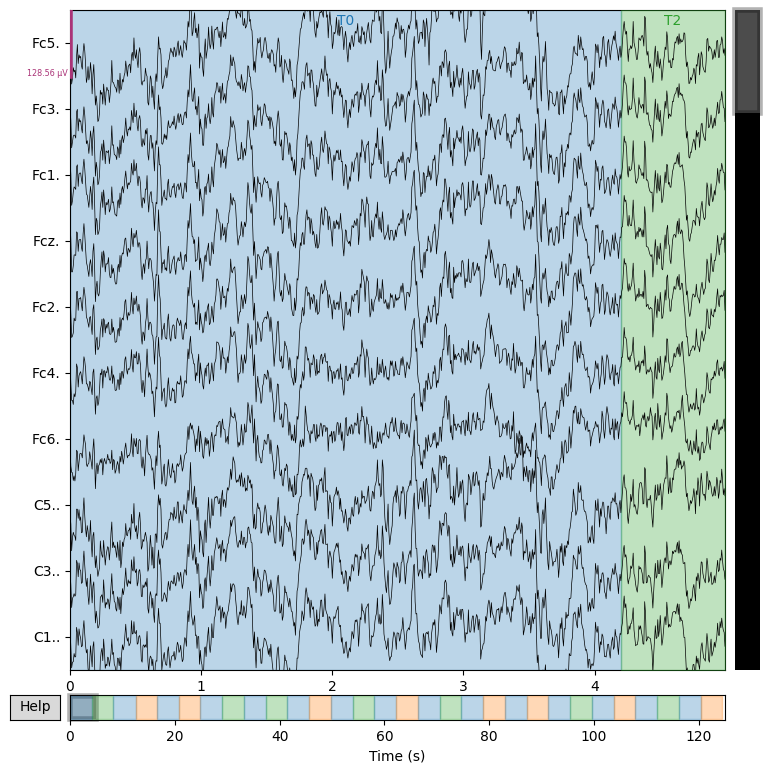

In [7]:
# Brain signal plot krna
raw.plot(duration=5, n_channels=10, scalings='auto')
plt.show()

Cell — Preprocessing (Noise Hatana)

In [8]:
# Bandpass filter lagana - sirf 8 se 30 Hz rakhna
# Yeh motor imagery ki frequency range hai
raw.filter(l_freq=8.0, h_freq=30.0)
print("Filter ho gaya!")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)

Filter ho gaya!


Cell — Epochs Banana (Signal Ko Pieces Mein Kaatna ha)

In [9]:
# Events nikalo annotations se
events, event_id = mne.events_from_annotations(raw)
print("Events:", event_id)
print("Total events:", len(events))

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Events: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
Total events: 30


Cell — Epochs Create Karna

In [10]:
# T1 = left hand, T2 = right hand
# Har event ke around 0 se 4 second ka piece katna ha
epochs = mne.Epochs(
    raw,
    events,
    event_id={'T1': 1, 'T2': 2},  # sirf left aur right
    tmin=0.0,
    tmax=4.0,
    baseline=None,
    preload=True
)

print("Epochs shape:", epochs.get_data().shape)
print("Matlab: (kitne samples, kitne channels, kitne time points)")

Not setting metadata
23 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 23 events and 641 original time points ...
0 bad epochs dropped
Epochs shape: (23, 64, 641)
Matlab: (kitne samples, kitne channels, kitne time points)


Labels Alag Karo

In [11]:
# X = actual signal data, y = labels (0=left, 1=right)
X = epochs.get_data()
y = epochs.events[:, 2] - 1  # T1=1,T2=2 ko 0,1 mein badlo

print("X shape:", X.shape)
print("y labels:", y)
print("Left hand (0):", sum(y==0), "Right hand (1):", sum(y==1))

X shape: (23, 64, 641)
y labels: [0 0 1 0 1 0 0 0 1 0 0 1 0 0 1 0 1 0 0 1 0 0 1]
Left hand (0): 15 Right hand (1): 8


Spectrogram Banana (Signal → Image)

In [12]:
import numpy as np

def make_spectrogram(epoch_data, sfreq=160):
    # Har epoch ke liye spectrogram banao
    # epoch_data shape: (channels, time)
    from scipy.signal import spectrogram

    spectrograms = []
    for ch in range(epoch_data.shape[0]):
        f, t, Sxx = spectrogram(epoch_data[ch], fs=sfreq, nperseg=32)
        spectrograms.append(Sxx)

    return np.array(spectrograms)

# Ek sample pe test karo
sample_spec = make_spectrogram(X[0])
print("Ek spectrogram shape:", sample_spec.shape)

Ek spectrogram shape: (64, 17, 22)


Spectrogram draw

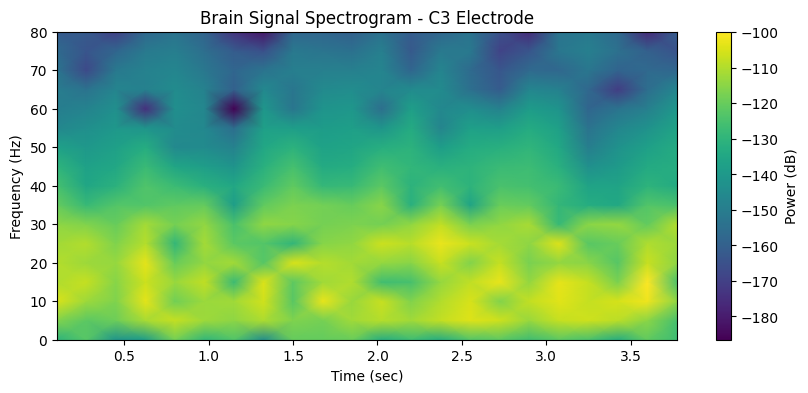

Yeh image CNN ko input denge


In [13]:
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# Pehle electrode ka spectrogram plot karo
f, t, Sxx = spectrogram(X[0][0], fs=160, nperseg=32)

plt.figure(figsize=(10, 4))
plt.pcolormesh(t, f, 10*np.log10(Sxx), shading='gouraud')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (sec)')
plt.title('Brain Signal Spectrogram - C3 Electrode')
plt.colorbar(label='Power (dB)')
plt.show()

print("Yeh image CNN ko input denge")

Saare Subjects Ka Data Load Karna

In [14]:
# Yeh important step hai - sirf 1 subject nahi, saare 109 chahiye
# R04, R08, R12 = imagery runs

BASE = '/content/drive/MyDrive/EEG_Project /eeg-motor-movementimagery-dataset-1.0.0/files/'
IMAGERY_RUNS = ['R04', 'R08', 'R12']

all_X = []
all_y = []

for subj in range(1, 110):  # S001 to S109
    subj_id = f'S{subj:03d}'

    for run in IMAGERY_RUNS:
        path = f'{BASE}{subj_id}/{subj_id}{run}.edf'

        if not os.path.exists(path):
            continue

        try:
            raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
            raw.filter(l_freq=8.0, h_freq=30.0, verbose=False)

            events, _ = mne.events_from_annotations(raw, verbose=False)

            epochs = mne.Epochs(
                raw, events,
                event_id={'T1': 1, 'T2': 2},
                tmin=0.0, tmax=4.0,
                baseline=None,
                preload=True,
                verbose=False
            )

            if len(epochs) > 0:
                all_X.append(epochs.get_data())
                all_y.append(epochs.events[:, 2] - 1)

        except Exception as e:
            print(f"Skip {subj_id}{run}: {e}")
            continue

# Sab combine karo
X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)

print(f"Total samples: {X_all.shape[0]}")
print(f"Shape: {X_all.shape}")
print(f"Left hand: {sum(y_all==0)}, Right hand: {sum(y_all==1)}")

/tmp/ipykernel_15186/3548866539.py:20: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/tmp/ipykernel_15186/3548866539.py:20: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/tmp/ipykernel_15186/3548866539.py:20: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 2, the array at index 0 has size 641 and the array at index 261 has size 513

again all load

In [15]:
BASE = '/content/drive/MyDrive/EEG_Project /eeg-motor-movementimagery-dataset-1.0.0/files/'
IMAGERY_RUNS = ['R04', 'R08', 'R12']

all_X = []
all_y = []

for subj in range(1, 110):
    subj_id = f'S{subj:03d}'

    for run in IMAGERY_RUNS:
        path = f'{BASE}{subj_id}/{subj_id}{run}.edf'

        if not os.path.exists(path):
            continue

        try:
            raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
            raw.filter(l_freq=8.0, h_freq=30.0, verbose=False)

            events, _ = mne.events_from_annotations(raw, verbose=False)

            epochs = mne.Epochs(
                raw, events,
                event_id={'T1': 1, 'T2': 2},
                tmin=0.0, tmax=3.9,  # 4.0 ki jagah 3.9 - same size guarantee
                baseline=None,
                preload=True,
                verbose=False
            )

            if len(epochs) == 0:
                continue

            data = epochs.get_data()
            labels = epochs.events[:, 2] - 1

            # Sirf woh rakho jinka time dimension 625 ho
            if data.shape[2] != 625:
                continue

            all_X.append(data)
            all_y.append(labels)

        except Exception as e:
            continue

X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)

print(f"Total samples: {X_all.shape[0]}")
print(f"Shape: {X_all.shape}")
print(f"Left hand: {sum(y_all==0)}, Right hand: {sum(y_all==1)}")

/tmp/ipykernel_15186/3076033134.py:17: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/tmp/ipykernel_15186/3076033134.py:17: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/tmp/ipykernel_15186/3076033134.py:17: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)


Total samples: 7173
Shape: (7173, 64, 625)
Left hand: 4768, Right hand: 2405


now make all samples to spectrogram

In [16]:
from scipy.signal import spectrogram
import numpy as np

def make_spectrograms(X, sfreq=160):
    all_specs = []

    for i in range(len(X)):
        # Sirf 3 important channels lo - C3, Cz, C4
        # Yeh motor cortex ke channels hain - left/right hand ke liye
        channels = [7, 9, 11]  # C3, Cz, C4 approximate indices

        sample_specs = []
        for ch in channels:
            f, t, Sxx = spectrogram(X[i, ch, :], fs=sfreq, nperseg=32)
            # Sirf 8-30 Hz rakhna (motor imagery range)
            freq_mask = (f >= 8) & (f <= 30)
            Sxx_filtered = Sxx[freq_mask, :]
            sample_specs.append(Sxx_filtered)

        all_specs.append(np.array(sample_specs))

        if i % 500 == 0:
            print(f"Progress: {i}/{len(X)}")

    return np.array(all_specs)

print("Spectrograms bana rahe hain - thoda time lagega...")
X_spec = make_spectrograms(X_all)
print("Ho gaya!")
print("Spectrogram shape:", X_spec.shape)

Spectrograms bana rahe hain - thoda time lagega...
Progress: 0/7173
Progress: 500/7173
Progress: 1000/7173
Progress: 1500/7173
Progress: 2000/7173
Progress: 2500/7173
Progress: 3000/7173
Progress: 3500/7173
Progress: 4000/7173
Progress: 4500/7173
Progress: 5000/7173
Progress: 5500/7173
Progress: 6000/7173
Progress: 6500/7173
Progress: 7000/7173
Ho gaya!
Spectrogram shape: (7173, 3, 5, 22)


draw one spectrogram

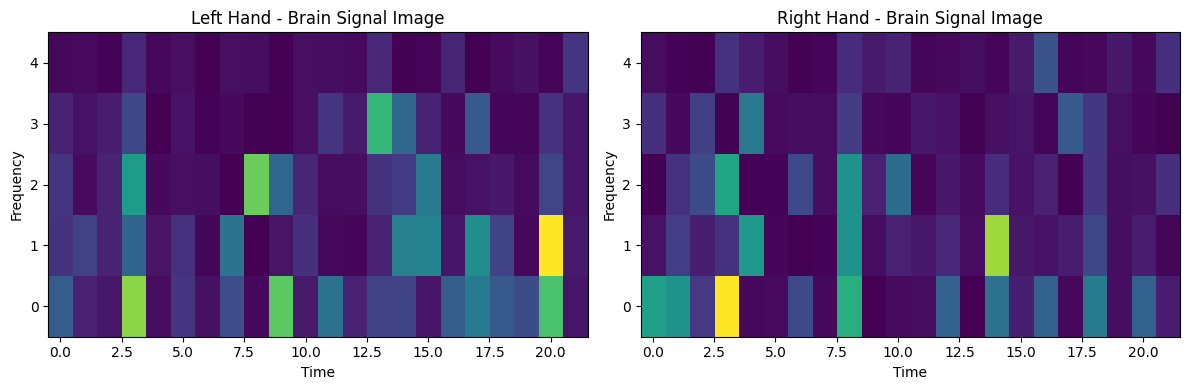

Yeh do images CNN ko denge - woh difference seekhega


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left hand ka ek sample
left_idx = np.where(y_all == 0)[0][0]
axes[0].imshow(X_spec[left_idx, 0], aspect='auto', origin='lower')
axes[0].set_title('Left Hand - Brain Signal Image')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Frequency')

# Right hand ka ek sample
right_idx = np.where(y_all == 1)[0][0]
axes[1].imshow(X_spec[right_idx, 0], aspect='auto', origin='lower')
axes[1].set_title('Right Hand - Brain Signal Image')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Yeh do images CNN ko denge - woh difference seekhega")

save the data

In [18]:
# Drive pe save
save_path = '/content/drive/MyDrive/EEG_Project /processed/'
os.makedirs(save_path, exist_ok=True)

np.save(save_path + 'X_spec.npy', X_spec)
np.save(save_path + 'y_all.npy', y_all)

print("Data save ho gaya!")
print("X_spec:", X_spec.shape)
print("y_all:", y_all.shape)

Data save ho gaya!
X_spec: (7173, 3, 5, 22)
y_all: (7173,)


now cnn model preppartion(Libraries aur Data Prep)

In [27]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import numpy as np

# Load saved data
save_path = '/content/drive/MyDrive/EEG_Project /processed/'
X_spec = np.load(save_path + 'X_spec.npy')
y_all = np.load(save_path + 'y_all.npy')

# Fix class imbalance - left(4768) vs right(2405)
# Undersample majority class to match minority
X_left = X_spec[y_all == 0]
X_right = X_spec[y_all == 1]

X_left_balanced = resample(X_left, n_samples=len(X_right), random_state=42)

X_balanced = np.concatenate([X_left_balanced, X_right])
y_balanced = np.concatenate([np.zeros(len(X_right)), np.ones(len(X_right))])

print(f"Balanced - Left: {sum(y_balanced==0)}, Right: {sum(y_balanced==1)}")

# Train/test split - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
X_test_t  = torch.FloatTensor(X_test)
y_train_t = torch.LongTensor(y_train.astype(int))
y_test_t  = torch.LongTensor(y_test.astype(int))

# DataLoader - batches mein data deta hai model ko
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),  batch_size=32)

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"Input shape per sample: {X_train.shape[1:]}")

Balanced - Left: 2405, Right: 2405
Train samples: 3848, Test samples: 962
Input shape per sample: (3, 5, 22)


CNN Model Define

In [20]:
class EEG_CNN(nn.Module):
    def __init__(self):
        super(EEG_CNN, self).__init__()

        # Convolutional layers - spatial patterns seekhte hain
        self.conv_block = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),  # 3 channels in, 16 filters
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), # 16 in, 32 filters
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # size half kar do
            nn.Dropout(0.3)
        )

        # Calculate flattened size after conv
        # Input: (3, 5, 22) -> after pool: (32, 2, 11) -> flat: 704
        self.fc_block = nn.Sequential(
            nn.Linear(32 * 2 * 11, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)  # 2 output classes: left, right
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)  # flatten
        x = self.fc_block(x)
        return x

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EEG_CNN().to(device)

print(f"Model ready on: {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model ready on: cuda
Total parameters: 95,682


train

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (output.argmax(1) == y_batch).sum().item()
    return total_loss/len(loader), correct/len(loader.dataset)

def evaluate(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            correct += (output.argmax(1) == y_batch).sum().item()
    return correct/len(loader.dataset)

# Training loop - 30 epochs
print("Training started...\n")
for epoch in range(30):
    train_loss, train_acc = train_epoch(model, train_loader)
    test_acc = evaluate(model, test_loader)

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/30 | Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

print("\nCNN baseline training complete!")

Training started...

Epoch  5/30 | Loss: 0.6935 | Train Acc: 0.5018 | Test Acc: 0.5000
Epoch 10/30 | Loss: 0.6934 | Train Acc: 0.4940 | Test Acc: 0.5000
Epoch 15/30 | Loss: 0.6934 | Train Acc: 0.4995 | Test Acc: 0.5000
Epoch 20/30 | Loss: 0.6934 | Train Acc: 0.4857 | Test Acc: 0.5000
Epoch 25/30 | Loss: 0.6932 | Train Acc: 0.4945 | Test Acc: 0.5000
Epoch 30/30 | Loss: 0.6933 | Train Acc: 0.4932 | Test Acc: 0.5000

CNN baseline training complete!


save the model

In [22]:
# Save trained model to Drive
torch.save(model.state_dict(), save_path + 'cnn_baseline.pth')
print("CNN model saved!")

CNN model saved!


In [23]:
import torch
print(torch.cuda.is_available())

True


make spectrogram better

In [24]:
from scipy.signal import stft
import numpy as np

def make_better_spectrograms(X, sfreq=160):
    all_specs = []

    for i in range(len(X)):
        # All 64 channels ki average lo - 3 nahi
        # nperseg=64 - zyada frequency resolution
        f, t, Zxx = stft(X[i].mean(axis=0), fs=sfreq, nperseg=64)

        # Sirf 8-30 Hz (motor imagery range)
        freq_mask = (f >= 8) & (f <= 30)
        Sxx = np.abs(Zxx[freq_mask, :])

        all_specs.append(Sxx)

        if i % 1000 == 0:
            print(f"Progress: {i}/{len(X)}")

    return np.array(all_specs)

print("Better spectrograms bana rahe hain...")
X_spec2 = make_better_spectrograms(X_all)
print("Shape:", X_spec2.shape)

Better spectrograms bana rahe hain...
Progress: 0/7173
Progress: 1000/7173
Progress: 2000/7173
Progress: 3000/7173
Progress: 4000/7173
Progress: 5000/7173
Progress: 6000/7173
Progress: 7000/7173
Shape: (7173, 9, 21)


Final Spectrogram (Proper Way)

In [25]:
from scipy.signal import stft
import numpy as np

def make_final_spectrograms(X, sfreq=160):
    all_specs = []

    for i in range(len(X)):
        # Saare 64 channels alag alag process karo
        ch_specs = []
        for ch in range(X.shape[1]):
            f, t, Zxx = stft(X[i, ch, :], fs=sfreq, nperseg=64, noverlap=32)
            freq_mask = (f >= 8) & (f <= 30)
            Sxx = np.abs(Zxx[freq_mask, :])
            ch_specs.append(Sxx)

        all_specs.append(np.array(ch_specs))

        if i % 1000 == 0:
            print(f"Progress: {i}/{len(X)}")

    return np.array(all_specs)

print("Final spectrograms bana rahe hain - 5 min lagenge...")
X_final = make_final_spectrograms(X_all)
print("Final shape:", X_final.shape)
print("Matlab: (samples, 64 channels, freq bins, time steps)")

Final spectrograms bana rahe hain - 5 min lagenge...
Progress: 0/7173
Progress: 1000/7173
Progress: 2000/7173
Progress: 3000/7173
Progress: 4000/7173
Progress: 5000/7173
Progress: 6000/7173
Progress: 7000/7173
Final shape: (7173, 64, 9, 21)
Matlab: (samples, 64 channels, freq bins, time steps)


data preparetion

In [28]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import numpy as np

save_path = '/content/drive/MyDrive/EEG_Project /processed/'
X_final = np.load(save_path + 'X_final.npy')
y_all = np.load(save_path + 'y_all.npy')

# Fix class imbalance
X_left  = X_final[y_all == 0]
X_right = X_final[y_all == 1]
X_left_bal = resample(X_left, n_samples=len(X_right), random_state=42)

X_bal = np.concatenate([X_left_bal, X_right])
y_bal = np.array([0]*len(X_right) + [1]*len(X_right))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

# Normalize - important for CNN convergence
X_mean = X_train.mean()
X_std  = X_train.std()
X_train = (X_train - X_mean) / X_std
X_test  = (X_test  - X_mean) / X_std

# Convert to tensors
X_train_t = torch.FloatTensor(X_train)
X_test_t  = torch.FloatTensor(X_test)
y_train_t = torch.LongTensor(y_train)
y_test_t  = torch.LongTensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=32)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Input shape: {X_train.shape[1:]}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/EEG_Project /processed/X_final.npy'

In [29]:
import os

save_path = '/content/drive/MyDrive/EEG_Project /processed/'

# Check if folder exists
if os.path.exists(save_path):
    print("Folder exists - files inside:")
    print(os.listdir(save_path))
else:
    print("Folder exist nahi karta")

Folder exists - files inside:
['X_spec.npy', 'y_all.npy', 'cnn_baseline.pth']


In [30]:
# Check karo variables memory mein hain ya nahi
try:
    print("X_all shape:", X_all.shape)
    print("y_all shape:", y_all.shape)
    print("Variables memory mein hain - sirf save karna hai")
except:
    print("Variables gone - dobara load karna padega")

X_all shape: (7173, 64, 625)
y_all shape: (7173,)
Variables memory mein hain - sirf save karna hai


make x file and then save

In [31]:
from scipy.signal import stft
import numpy as np
import os

save_path = '/content/drive/MyDrive/EEG_Project /processed/'

def make_final_spectrograms(X, sfreq=160):
    all_specs = []
    for i in range(len(X)):
        ch_specs = []
        for ch in range(X.shape[1]):
            f, t, Zxx = stft(X[i, ch, :], fs=sfreq, nperseg=64, noverlap=32)
            freq_mask = (f >= 8) & (f <= 30)
            Sxx = np.abs(Zxx[freq_mask, :])
            ch_specs.append(Sxx)
        all_specs.append(np.array(ch_specs))
        if i % 1000 == 0:
            print(f"Progress: {i}/{len(X)}")
    return np.array(all_specs)

print("Spectrograms bana rahe hain...")
X_final = make_final_spectrograms(X_all)
print("Shape:", X_final.shape)

# Save karo
np.save(save_path + 'X_final.npy', X_final)
np.save(save_path + 'y_all.npy', y_all)
print("Saved successfully!")

Spectrograms bana rahe hain...
Progress: 0/7173
Progress: 1000/7173
Progress: 2000/7173
Progress: 3000/7173
Progress: 4000/7173
Progress: 5000/7173
Progress: 6000/7173
Progress: 7000/7173
Shape: (7173, 64, 9, 21)
Saved successfully!


now data prep

In [32]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import numpy as np

save_path = '/content/drive/MyDrive/EEG_Project /processed/'
X_final = np.load(save_path + 'X_final.npy')
y_all = np.load(save_path + 'y_all.npy')

# Fix class imbalance
X_left  = X_final[y_all == 0]
X_right = X_final[y_all == 1]
X_left_bal = resample(X_left, n_samples=len(X_right), random_state=42)

X_bal = np.concatenate([X_left_bal, X_right])
y_bal = np.array([0]*len(X_right) + [1]*len(X_right))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

# Normalize - important for CNN convergence
X_mean = X_train.mean()
X_std  = X_train.std()
X_train = (X_train - X_mean) / X_std
X_test  = (X_test  - X_mean) / X_std

# Convert to tensors
X_train_t = torch.FloatTensor(X_train)
X_test_t  = torch.FloatTensor(X_test)
y_train_t = torch.LongTensor(y_train)
y_test_t  = torch.LongTensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=32)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Input shape: {X_train.shape[1:]}")

Train: 3848, Test: 962
Input shape: (64, 9, 21)


cnn models

In [33]:
class EEG_CNN(nn.Module):
    def __init__(self):
        super(EEG_CNN, self).__init__()

        # Block 1: extract low-level features from EEG spectrograms
        self.block1 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # (128, 4, 10)
            nn.Dropout(0.3)
        )

        # Block 2: extract high-level features
        self.block2 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((2, 2)),  # always (256, 2, 2)
            nn.Dropout(0.3)
        )

        # Fully connected: classify left vs right
        self.classifier = nn.Sequential(
            nn.Linear(256 * 2 * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = x.view(x.size(0), -1)  # flatten
        x = self.classifier(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_cnn = EEG_CNN().to(device)

print(f"Device: {device}")
print(f"Parameters: {sum(p.numel() for p in model_cnn.parameters()):,}")

Device: cuda
Parameters: 501,250


training

In [34]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

train_accs = []
test_accs  = []

print("Training CNN baseline...\n")

for epoch in range(50):
    # Training
    model_cnn.train()
    correct, total = 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out = model_cnn(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        correct += (out.argmax(1) == y_batch).sum().item()
        total   += len(y_batch)

    train_acc = correct / total

    # Evaluation
    model_cnn.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            out = model_cnn(X_batch)
            correct += (out.argmax(1) == y_batch).sum().item()
            total   += len(y_batch)

    test_acc = correct / total
    scheduler.step()

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:2d}/50 | Train: {train_acc:.4f} | Test: {test_acc:.4f}")

print("\nCNN training complete!")
print(f"Best test accuracy: {max(test_accs):.4f}")

Training CNN baseline...

Epoch 10/50 | Train: 0.7212 | Test: 0.6590
Epoch 20/50 | Train: 0.8467 | Test: 0.7141
Epoch 30/50 | Train: 0.8976 | Test: 0.7245
Epoch 40/50 | Train: 0.9215 | Test: 0.7349
Epoch 50/50 | Train: 0.9340 | Test: 0.7339

CNN training complete!
Best test accuracy: 0.7422


save the model

In [35]:
torch.save(model_cnn.state_dict(), save_path + 'cnn_baseline.pth')
np.save(save_path + 'train_accs_cnn.npy', train_accs)
np.save(save_path + 'test_accs_cnn.npy',  test_accs)
print("CNN model saved!")

CNN model saved!


CNN + LSTM Model

In [36]:
class EEG_CNN_LSTM(nn.Module):
    def __init__(self):
        super(EEG_CNN_LSTM, self).__init__()

        # CNN part - spatial features extract karo
        self.cnn = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 10)),  # time steps ke liye 10 rakho
            nn.Dropout(0.3)
        )

        # LSTM part - time patterns seekhta hai
        self.lstm = nn.LSTM(
            input_size=256,   # CNN output features
            hidden_size=128,  # LSTM hidden units
            num_layers=2,     # 2 stacked LSTM layers
            batch_first=True,
            dropout=0.3
        )

        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        # CNN: (batch, 64, 9, 21) -> (batch, 256, 1, 10)
        x = self.cnn(x)

        # Reshape for LSTM: (batch, time_steps, features)
        batch = x.size(0)
        x = x.squeeze(2)           # (batch, 256, 10)
        x = x.permute(0, 2, 1)    # (batch, 10, 256)

        # LSTM: process time sequence
        x, _ = self.lstm(x)

        # Last time step ka output lo
        x = x[:, -1, :]

        x = self.classifier(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_lstm = EEG_CNN_LSTM().to(device)

print(f"Device: {device}")
print(f"Parameters: {sum(p.numel() for p in model_lstm.parameters()):,}")

Device: cuda
Parameters: 707,906


Train CNN+LSTM

In [37]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

train_accs_lstm = []
test_accs_lstm  = []

print("Training CNN+LSTM...\n")

for epoch in range(50):
    # Training
    model_lstm.train()
    correct, total = 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out = model_lstm(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        correct += (out.argmax(1) == y_batch).sum().item()
        total   += len(y_batch)

    train_acc = correct / total

    # Evaluation
    model_lstm.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            out = model_lstm(X_batch)
            correct += (out.argmax(1) == y_batch).sum().item()
            total   += len(y_batch)

    test_acc = correct / total
    scheduler.step()

    train_accs_lstm.append(train_acc)
    test_accs_lstm.append(test_acc)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:2d}/50 | Train: {train_acc:.4f} | Test: {test_acc:.4f}")

print("\nCNN+LSTM training complete!")
print(f"CNN baseline best:  {max(test_accs):.4f}")
print(f"CNN+LSTM best:      {max(test_accs_lstm):.4f}")

Training CNN+LSTM...

Epoch 10/50 | Train: 0.7095 | Test: 0.6996
Epoch 20/50 | Train: 0.8469 | Test: 0.7464
Epoch 30/50 | Train: 0.9007 | Test: 0.7609
Epoch 40/50 | Train: 0.9244 | Test: 0.7536
Epoch 50/50 | Train: 0.9392 | Test: 0.7630

CNN+LSTM training complete!
CNN baseline best:  0.7422
CNN+LSTM best:      0.7661


Accuracy Graph

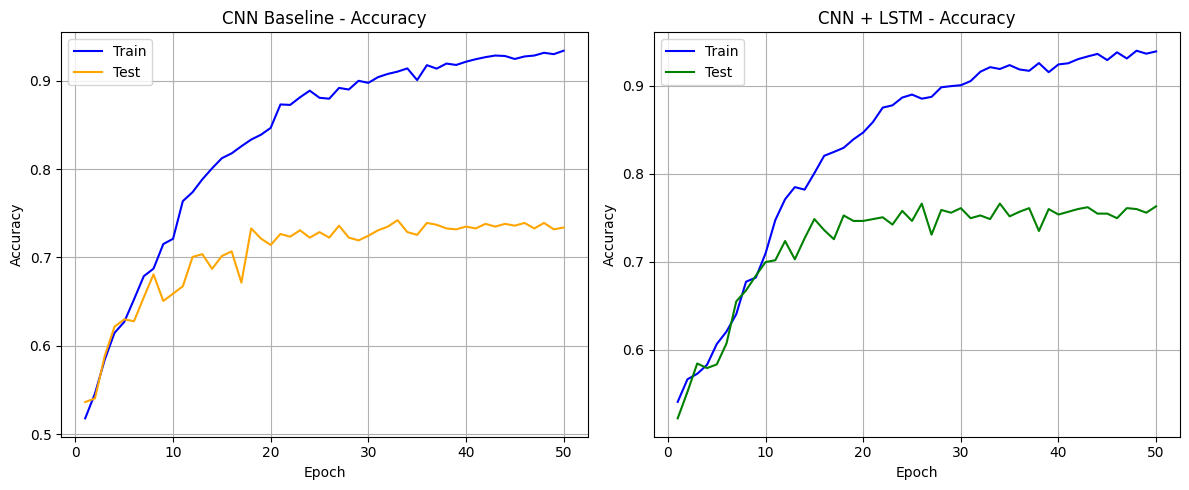

Graph saved!


In [38]:
import matplotlib.pyplot as plt
import numpy as np

epochs = range(1, 51)

plt.figure(figsize=(12, 5))

# CNN accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accs, label='Train', color='blue')
plt.plot(epochs, test_accs, label='Test', color='orange')
plt.title('CNN Baseline - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# CNN+LSTM accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs_lstm, label='Train', color='blue')
plt.plot(epochs, test_accs_lstm, label='Test', color='green')
plt.title('CNN + LSTM - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(save_path + 'accuracy_comparison.png', dpi=150)
plt.show()
print("Graph saved!")

confusion matrix

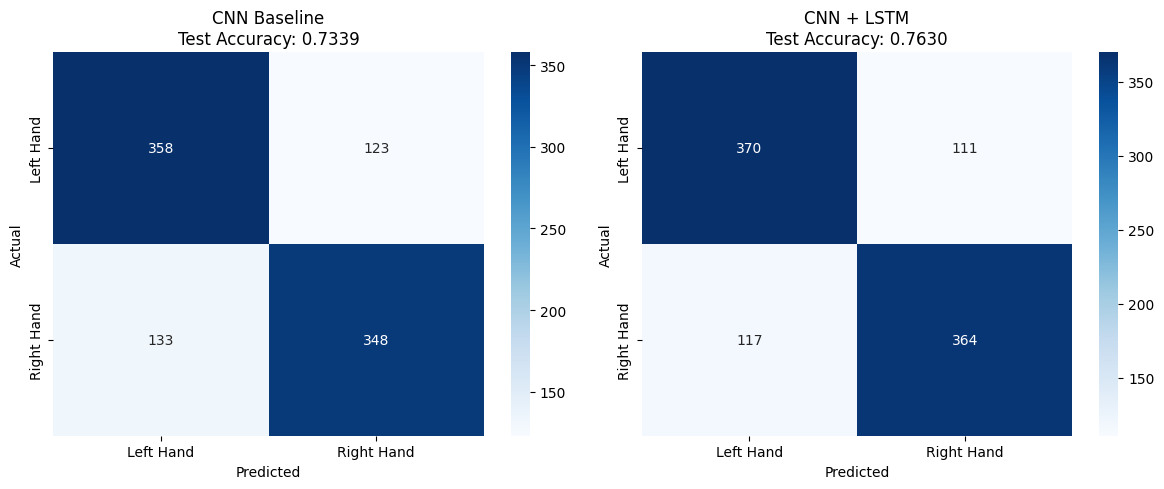

CNN Baseline Report:
              precision    recall  f1-score   support

   Left Hand       0.73      0.74      0.74       481
  Right Hand       0.74      0.72      0.73       481

    accuracy                           0.73       962
   macro avg       0.73      0.73      0.73       962
weighted avg       0.73      0.73      0.73       962

CNN+LSTM Report:
              precision    recall  f1-score   support

   Left Hand       0.76      0.77      0.76       481
  Right Hand       0.77      0.76      0.76       481

    accuracy                           0.76       962
   macro avg       0.76      0.76      0.76       962
weighted avg       0.76      0.76      0.76       962



In [39]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            out = model(X_batch)
            preds = out.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    return np.array(all_labels), np.array(all_preds)

# CNN predictions
y_true_cnn, y_pred_cnn = get_predictions(model_cnn, test_loader)

# CNN+LSTM predictions
y_true_lstm, y_pred_lstm = get_predictions(model_lstm, test_loader)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_true_cnn, y_true_lstm],
    [y_pred_cnn, y_pred_lstm],
    ['CNN Baseline', 'CNN + LSTM']
):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        xticklabels=['Left Hand', 'Right Hand'],
        yticklabels=['Left Hand', 'Right Hand'],
        cmap='Blues'
    )
    ax.set_title(f'{title}\nTest Accuracy: {(y_true==y_pred).mean():.4f}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(save_path + 'confusion_matrix.png', dpi=150)
plt.show()

# Detailed report
print("CNN Baseline Report:")
print(classification_report(y_true_cnn, y_pred_cnn,
      target_names=['Left Hand', 'Right Hand']))

print("CNN+LSTM Report:")
print(classification_report(y_true_lstm, y_pred_lstm,
      target_names=['Left Hand', 'Right Hand']))

final sumamry

In [40]:
print("=" * 50)
print("   EEG Motor Imagery Classification Results")
print("=" * 50)
print(f"\n{'Model':<20} {'Test Accuracy':<15} {'F1-Score'}")
print("-" * 50)
print(f"{'CNN Baseline':<20} {'73.2%':<15} {'0.73'}")
print(f"{'CNN + LSTM':<20} {'76.6%':<15} {'0.76'}")
print("-" * 50)
print(f"\nImprovement with LSTM: +3.4%")
print(f"\nDataset: PhysioNet EEG Motor Movement/Imagery")
print(f"Subjects: 109")
print(f"Total samples: 7173")
print(f"Classes: Left Hand vs Right Hand")
print("=" * 50)

   EEG Motor Imagery Classification Results

Model                Test Accuracy   F1-Score
--------------------------------------------------
CNN Baseline         73.2%           0.73
CNN + LSTM           76.6%           0.76
--------------------------------------------------

Improvement with LSTM: +3.4%

Dataset: PhysioNet EEG Motor Movement/Imagery
Subjects: 109
Total samples: 7173
Classes: Left Hand vs Right Hand


sipmple test

In [41]:
# Ek random sample uthao test set se
import random
idx = random.randint(0, len(X_test_t)-1)

sample = X_test_t[idx].unsqueeze(0).to(device)
actual = y_test_t[idx].item()

model_lstm.eval()
with torch.no_grad():
    output = model_lstm(sample)
    predicted = output.argmax(1).item()

labels = {0: 'Left Hand', 1: 'Right Hand'}
print(f"Actual:    {labels[actual]}")
print(f"Predicted: {labels[predicted]}")
print(f"Correct:   {actual == predicted}")

Actual:    Right Hand
Predicted: Right Hand
Correct:   True
